In [4]:
# Import
import os, time
import torch
import torch.nn as nn
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import glob
from torch.utils.data import TensorDataset, random_split, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from sklearn.metrics import roc_auc_score, average_precision_score, PrecisionRecallDisplay, RocCurveDisplay
#from resnet import ResNet1d
%matplotlib inline
from flwr.app import MetricRecord
#plt.style.available
#'seaborn-v0_8-white', 'whitegrid' -- plt.style.use
#plt.style.use('seaborn-v0_8-white')

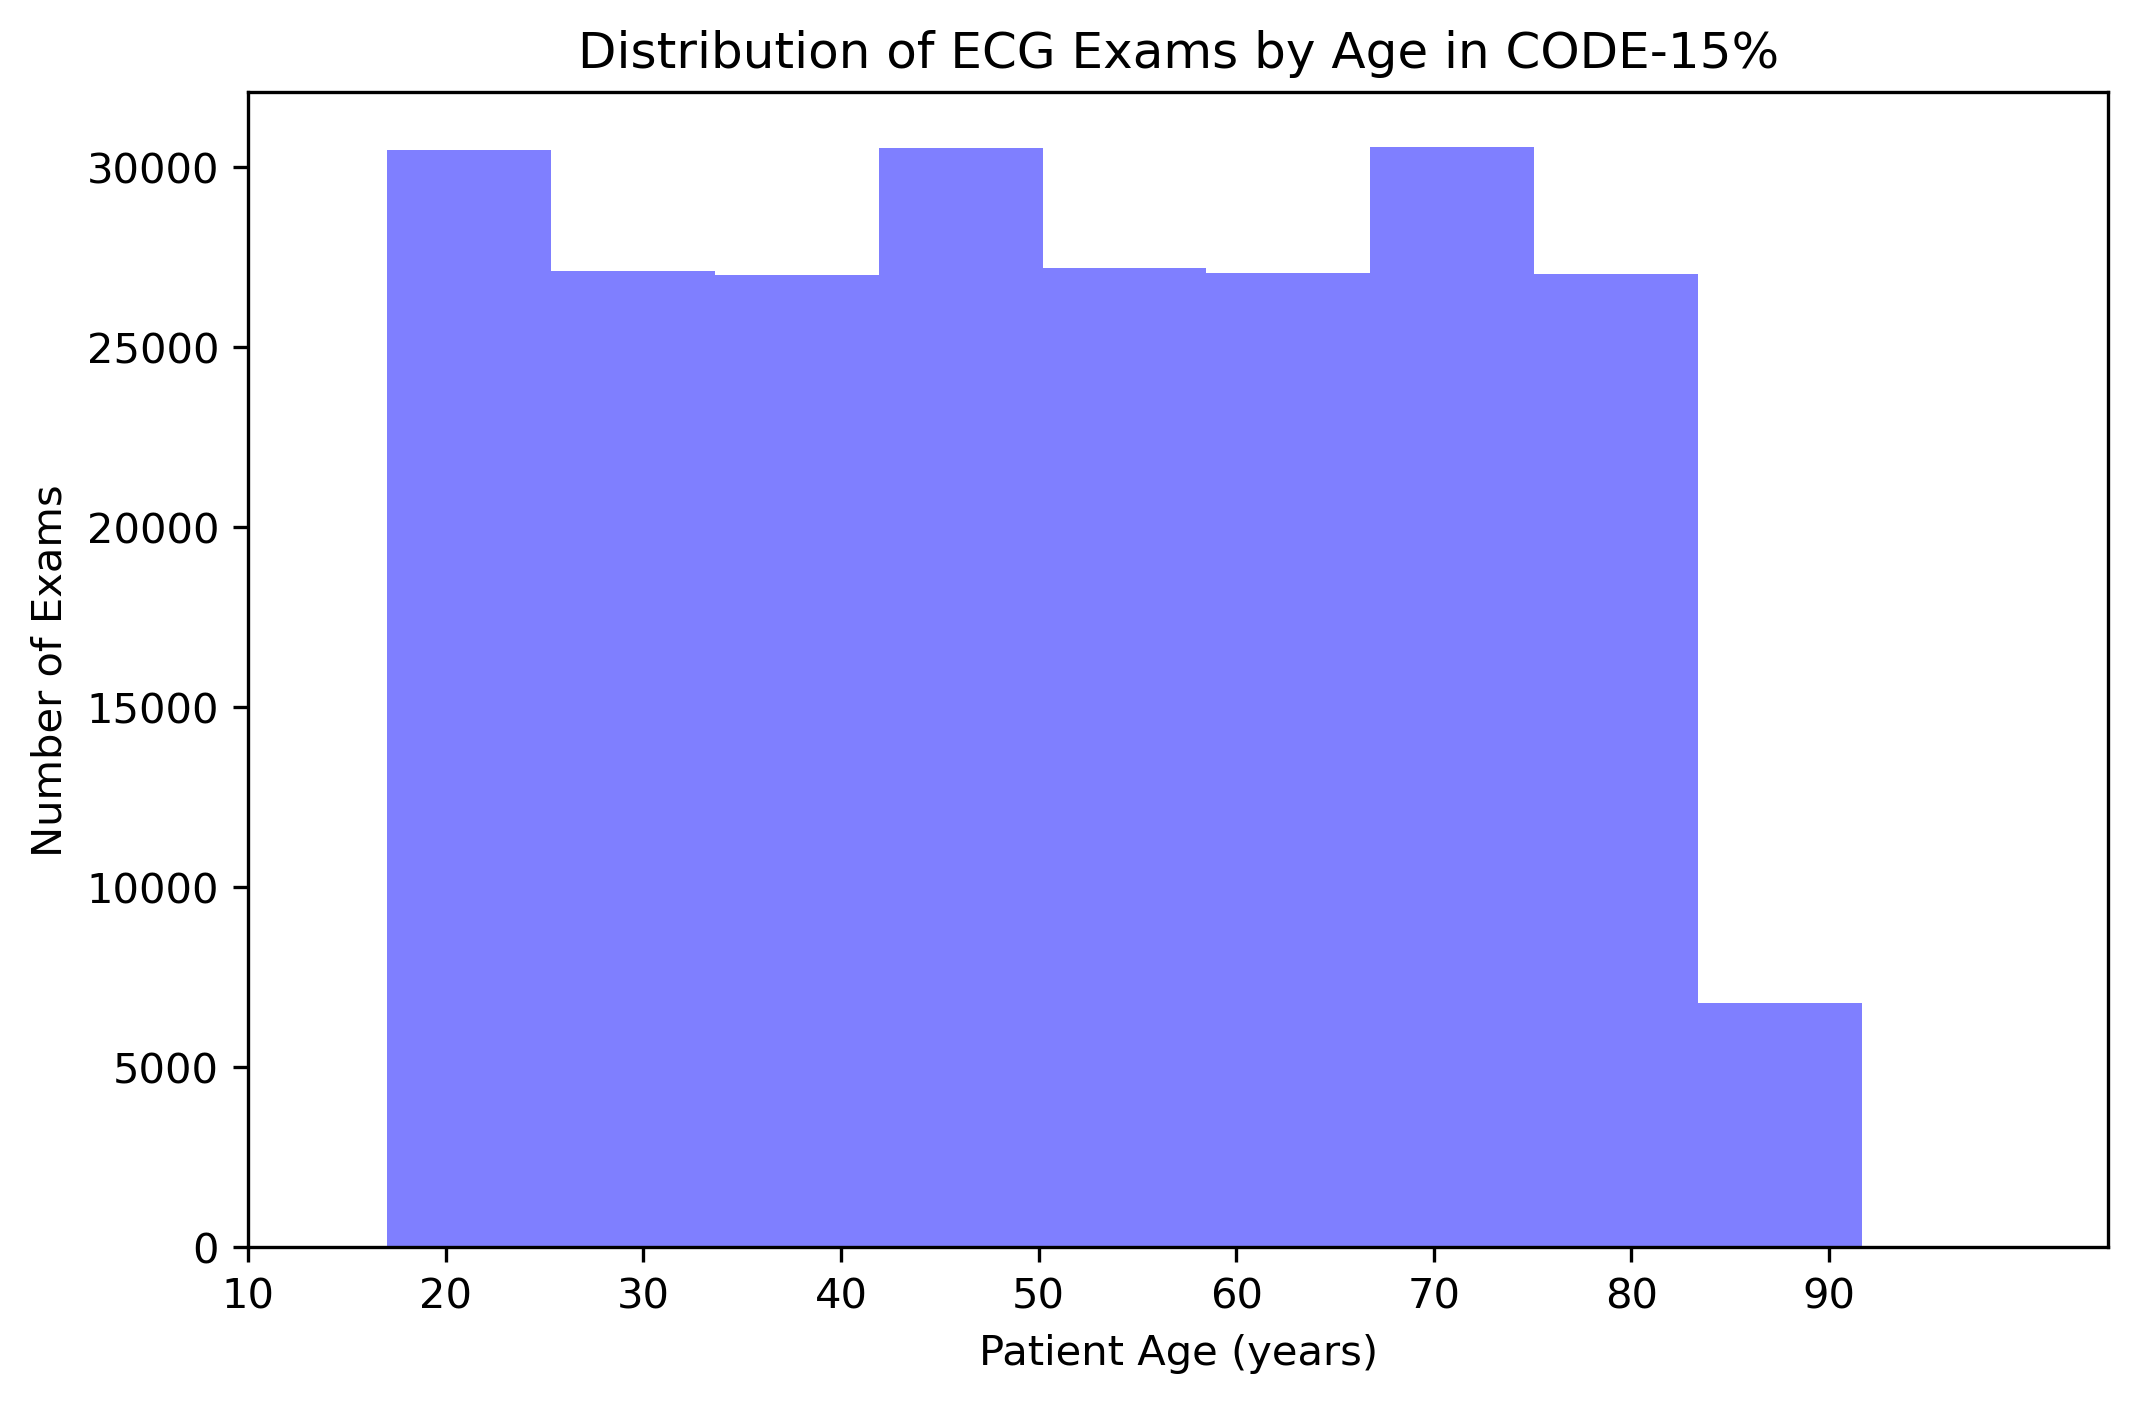

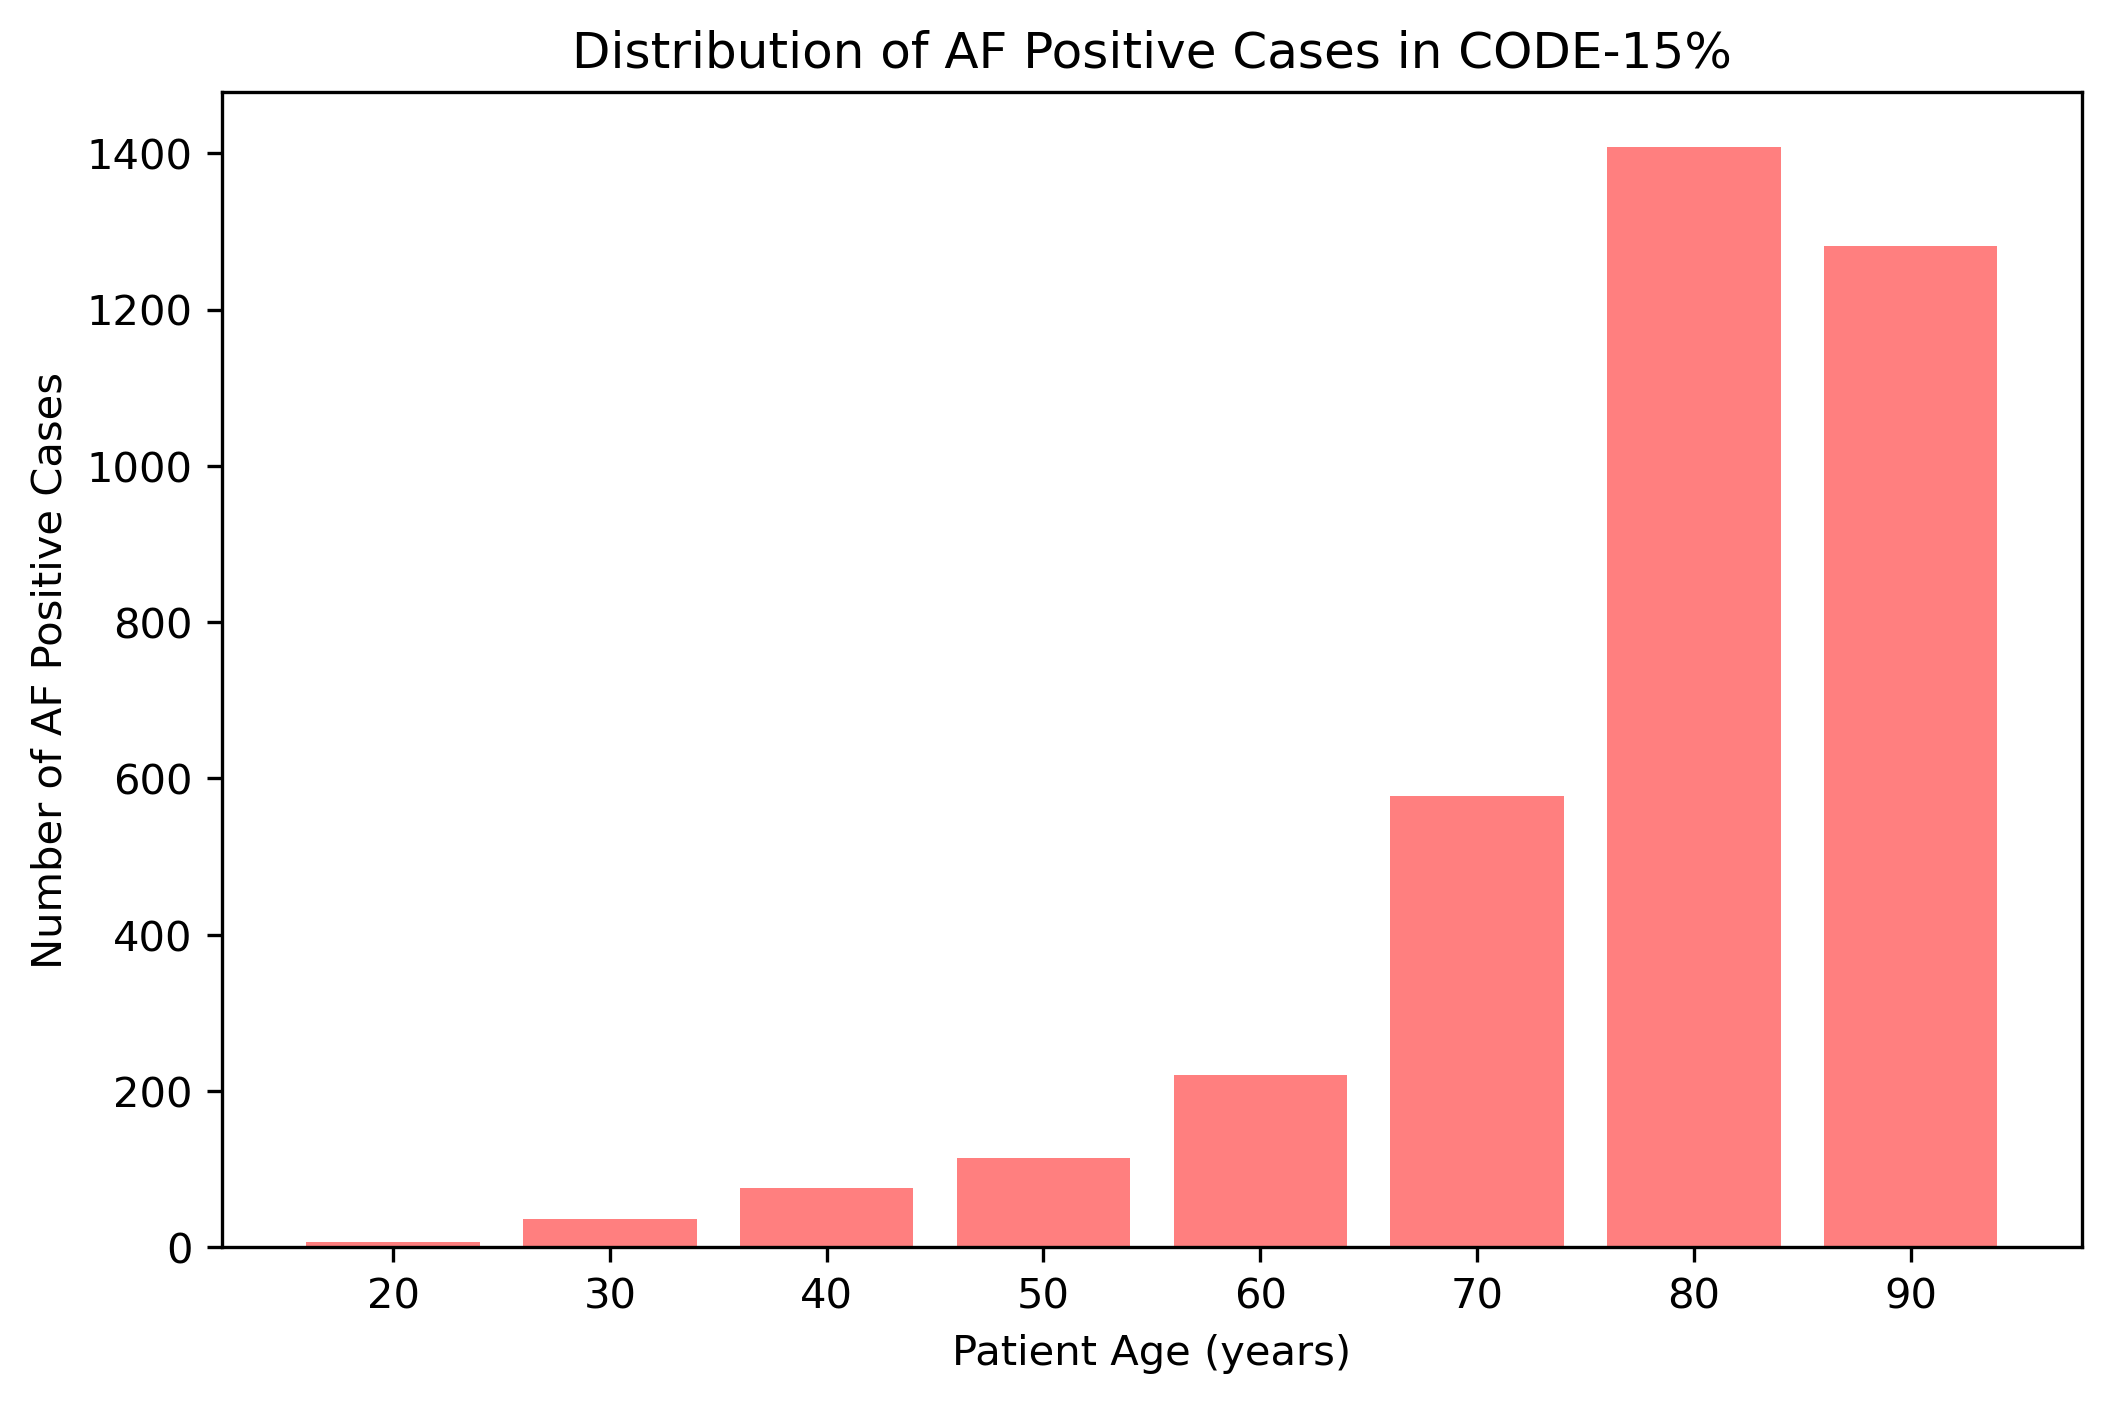

In [5]:
# drawing a histogram of ages of patients in the dataset
# in the same plot, show a second y-axis and show the positive AF count as bars as well
# this should show the positive AF count as per the age bin
df = pd.read_csv("../exams.csv")
df = df.drop_duplicates(subset=["patient_id"], keep="last").dropna(subset=["AF"])
fig, ax1 = plt.subplots(figsize=(8,5), dpi=300)
ax1.set_title("Distribution of ECG Exams by Age in CODE-15%")
ax1.set_xlabel("Patient Age (years)")
ax1.set_ylabel("Number of Exams")
ax1.hist(df['age'], bins=10, alpha=0.5, color="blue")
fig2, ax2 = plt.subplots(figsize=(8,5), dpi=300)
ax2.set_title("Distribution of AF Positive Cases in CODE-15%")
ax2.set_ylabel("Number of AF Positive Cases")
ax2.set_xlabel("Patient Age (years)")
# modify x-axis to show age bins of 10 years
ax1.set_xticks(np.arange(10, 100, 10))
age_bins = np.arange(10, 100, 10)
af_positive_counts = [df[(df['age'] >= age_bins[i]) & (df['age'] < age_bins[i+1]) & (df['AF'] == 1)].shape[0] for i in range(len(age_bins)-1)]
ax2.bar(age_bins[:-1]+10, af_positive_counts, width=8, alpha=0.5, color="red")
#ax1.legend(loc='upper right')
#ax2.legend() should be below ax1.legend() to avoid overlap
#ax2.legend(loc='lower right')
plt.show()

In [21]:
df = pd.read_csv("../2-soa-model-ecg/exams(2).csv")
df = df[~df.trace_file.isin(["exams_part0.hdf5","exams_part1.hdf5","exams_part2.hdf5","exams_part3.hdf5"])].drop_duplicates(subset=["patient_id"], keep="last").dropna(subset=["AF"])
#df[df["AF"]==1].shape[0]/df.shape[0]
print(df[df['AF']==0].shape[0]/df[df['AF']==1].shape[0])
#print(df[df['AF']==1].shape[0])
#print(df[df['AF']==0].shape[0])
#print(df[df['AF']==1].shape[0]/df[df['AF']==0].shape[0])
#print(df[df['is_male']==1].shape[0]/df.shape[0])
#df

60.16379310344828


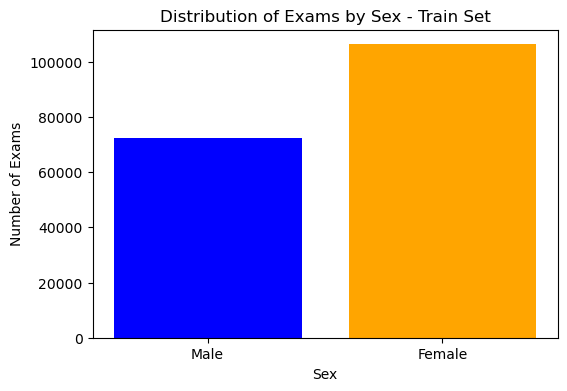

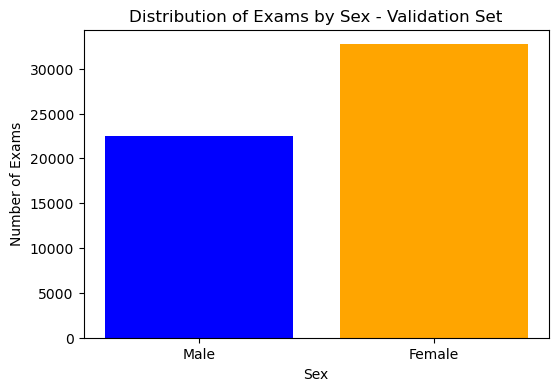

In [11]:
# plot for number of male and female exams from dataframe
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot()
train = df[~df.trace_file.isin(["exams_part0.hdf5","exams_part1.hdf5","exams_part2.hdf5","exams_part3.hdf5"])].copy()
ax.set_title("Distribution of Exams by Sex - Train Set")
ax.set_xlabel("Sex")
ax.set_ylabel("Number of Exams")
ax.bar(["Male", "Female"], [train[train['is_male']==1].shape[0], train[train['is_male']==0].shape[0]], color=["blue", "orange"])

fig2 = plt.figure(figsize=(6,4))
ax2 = fig2.add_subplot()
valid = df[df.trace_file.isin(["exams_part0.hdf5","exams_part1.hdf5","exams_part2.hdf5","exams_part3.hdf5"])].copy()
ax2.set_title("Distribution of Exams by Sex - Validation Set")
ax2.set_xlabel("Sex")
ax2.set_ylabel("Number of Exams")
ax2.bar(["Male", "Female"], [valid[valid['is_male']==1].shape[0], valid[valid['is_male']==0].shape[0]], color=["blue", "orange"])

plt.show()

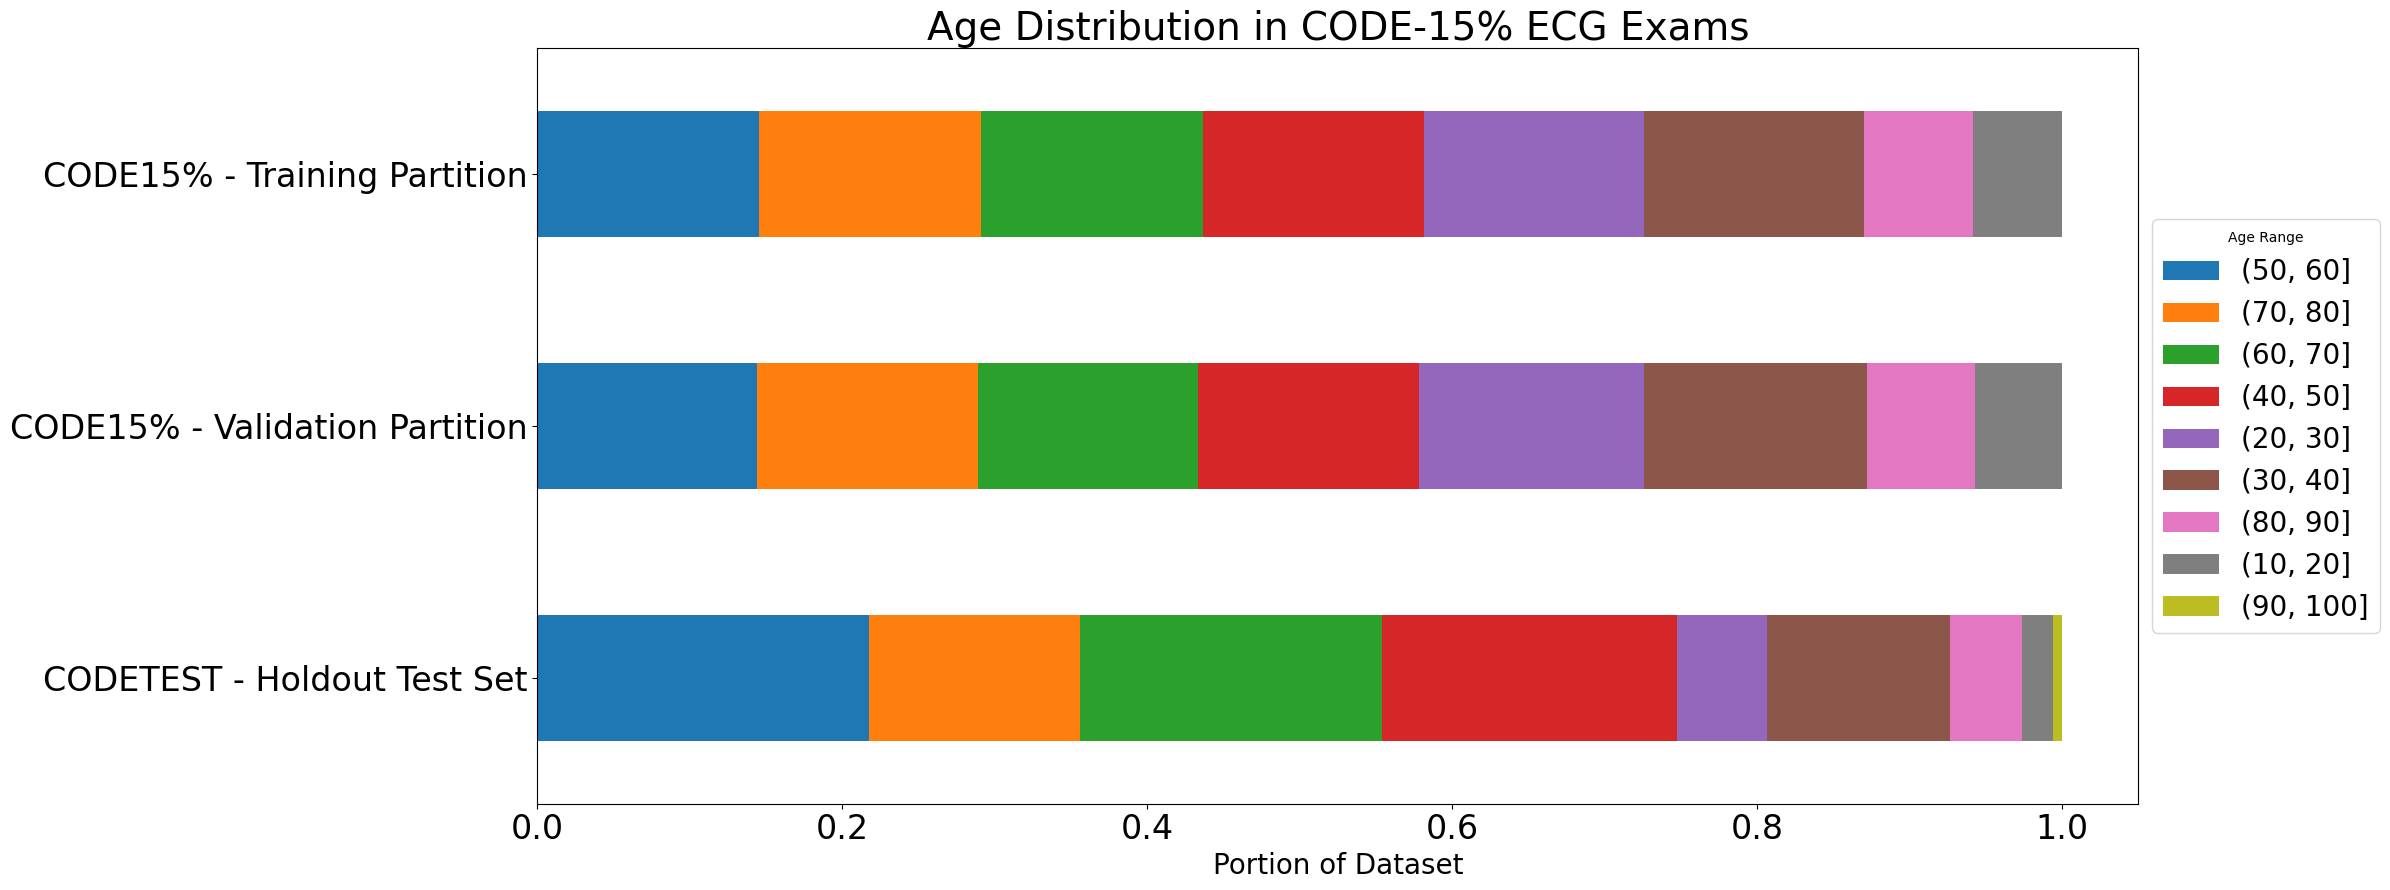

In [78]:
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100] 
labels = [str(i) for i in bins]

train = df[~df.trace_file.isin(["exams_part0.hdf5","exams_part1.hdf5","exams_part2.hdf5","exams_part3.hdf5"])].copy()
valid = df[df.trace_file.isin(["exams_part0.hdf5","exams_part1.hdf5","exams_part2.hdf5","exams_part3.hdf5"])].copy()
test = pd.read_csv("code-test/attributes.csv")

train["age_bins"] = pd.cut(train["age"], bins, labels)
valid["age_bins"] = pd.cut(valid["age"], bins, labels)
test["age_bins"] = pd.cut(test["age"], bins, labels)

train_counts = train["age_bins"].value_counts(
    normalize=True
).to_frame()
train_counts["validation"] = valid["age_bins"].value_counts(
    normalize=True
)
train_counts["test"] = test["age_bins"].value_counts(
    normalize=True
)

sets = ['CODE15% - Training Partition', 'CODE15% - Validation Partition', 'CODETEST - Holdout Test Set']
train_counts.columns = sets
ax = train_counts[sorted(sets, reverse=True)].T.plot.barh(stacked=True, figsize=(24, 9), fontsize=24)
plt.title("Age Distribution in CODE-15% ECG Exams", fontsize=28)
plt.xlabel("Portion of Dataset", fontsize=20)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title="Age Range", fontsize=20)

# annotations:
for c in ax.containers:   
    # format the number of decimal places and replace 0 with an empty string
    labels = [f'{w*100:.4f}%' if (w := v.get_width()) > 1 else '' for v in c]
    #ax.bar_label(c, labels=sorted(labels), label_type='edge')
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.ticker import MaxNLocator
import pandas as pd
import matplotlib.pyplot as plt
d = pd.read_csv("../centralized.csv")

fig2 = plt.figure(figsize=(6,4), dpi=300)
ax2 = fig2.add_subplot()
ax2.set_title("Avg. Precision and ROC/AUC - Centralized Training on 160K ECG Exams")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("PR-AUC")
ax2.plot(d["epoch"], d["mAP"], color="blue", label="PR-AUC")
ax2.plot(d["epoch"], d["ROC/AUC"], color="orange", label="ROC/AUC")
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend(loc="best")
fig2.tight_layout()

fig3 = plt.figure(figsize=(6,4), dpi=300)
ax3 = fig3.add_subplot()
ax3.set_title("Loss Curves - Centralized Training on 160K ECG Exams")
ax3.set_xlabel("Iterations")
ax3.set_ylabel("Loss")
ax3.plot(d["epoch"], d["train_loss"], color="blue", label="Training Loss")
ax3.plot(d["epoch"], d["valid_loss"], color="orange", label="Validation Loss")
ax3.legend(loc="best")
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
fig3.tight_layout()
plt.show()